In [7]:
from sage.all import *
lst=[]
precision = 10
N=5
k=4
S = CuspForms(N, k)
d = S.dimension()
print("*****************************************************************************************")
print("(N,k):",(N,k),"dimension CuspForms(N,k):",d)
S = CuspForms(N,k)
print("For the CuspForms(N,k), echelon basis:")
for f in S.basis():
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("basis member:")
    print(f.q_expansion(precision))
    Ks = f.base_ring()
    print("field of coefficients Ks of the echelon basis member in CuspForms(N,k):",   Ks)
    print("[Ks:Q]:",Ks.degree())
    print("field polynomial:")
    poly = Ks.polynomial()
    print(poly)
    print("roots:")
    print(poly.roots(ring=SR, multiplicities=False)) 
    print("-------------------------------------------------------------------------")
    print("For the CuspForms(N,k) eigenbasis (let a vary over the root set):")
for f in S.newforms(names='a'):
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("basis member:")
    print(f.q_expansion(precision))
    Ke = f.base_ring()
    print("field of coefficients Ke of the eigenbasis member in CuspForms(N,k):",Ke)
    print("[Ke:Q]:",Ke.degree())
    print("field polynomial:")
    poly = Ke.polynomial()
    print(poly)
    print("roots:")
    print(poly.roots(ring=SR, multiplicities=False))

*****************************************************************************************
(N,k): (5, 4) dimension CuspForms(N,k): 1
For the CuspForms(N,k), echelon basis:
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
basis member:
q - 4*q^2 + 2*q^3 + 8*q^4 - 5*q^5 - 8*q^6 + 6*q^7 - 23*q^9 + O(q^10)
field of coefficients Ks of the echelon basis member in CuspForms(N,k): Rational Field
[Ks:Q]: 1
field polynomial:
x
roots:
[0]
-------------------------------------------------------------------------
For the CuspForms(N,k) eigenbasis (let a vary over the root set):
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
basis member:
q - 4*q^2 + 2*q^3 + 8*q^4 - 5*q^5 - 8*q^6 + 6*q^7 - 23*q^9 + O(q^10)
field of coefficients Ke of the eigenbasis member in CuspForms(N,k): Rational Field
[Ke:Q]: 1
field polynomial:
x
roots:
[0]


In [1]:
from sage.all import *


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return tr

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)

        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return results

precision=20
N=5
k=4
gos=galois_orbit_sum(N,k,precision)
print("length:",len(gos))
print(gos[0][:10]) 



length: 1
[0, 1, -4, 2, 8, -5, -8, 6, 0, -23]


In [10]:
import pickle
import time

start=time.time()

def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return tr

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)

        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return results


N=5
k=4
precision=500 # need a long list to find 350 primes
gos=galois_orbit_sum(N, k, precision)
print(gos[0][:10])
gos=gos[0][1:] # gos has just one newform and this line deletes its constant term
print(gos[:10])

indexed_list=[(n,gos[n]) for n in range(1,len(gos[0]))] # <<<<<<<<<<<<<<<<<< start with cff of q^1 

[0, 1, -4, 2, 8, -5, -8, 6, 0, -23]
[1, -4, 2, 8, -5, -8, 6, 0, -23, 20]


TypeError: object of type 'sage.rings.rational.Rational' has no len()

[0, 1, -4, 2, 8, -5, -8, 6, 0, -23]
('j_list', 20)
('j_list', 40)
('j_list', 60)
('j_list', 80)
('j_list', 100)
('j_list', 120)
('j_list', 140)
('j_list', 160)
('j_list', 180)
('j_list', 200)
('j_list', 220)
('j_list', 240)
('j_list', 260)
('j_list', 280)
('j_list', 300)
('j_list', 320)
('j_list', 340)
('j_list', 360)
('j_list', 380)
('j_list', 400)
(1, 0.002047936121622721)
(2, 0.0030529181162516276)
(3, 0.0034613847732543946)
(4, 0.003560368220011393)
(5, 0.0036234656969706216)
(6, 0.003692185878753662)
(7, 0.003728318214416504)
(8, 0.0037670016288757326)
(9, 0.003813167413075765)
(10, 0.003901652495066325)
(11, 0.003970217704772949)
(12, 0.004057753086090088)
(13, 0.004176286856333414)
(14, 0.004322437445322672)
(15, 0.004452617963155111)
(16, 0.004645498593648275)
(17, 0.004803232351938884)
(18, 0.0050255020459493)
(19, 0.005259966850280762)
(20, 0.005528136094411214)
(21, 0.005763852596282959)
(22, 0.006076951821645101)
(23, 0.006459101041158041)
(24, 0.006789767742156982)
(25, 0.

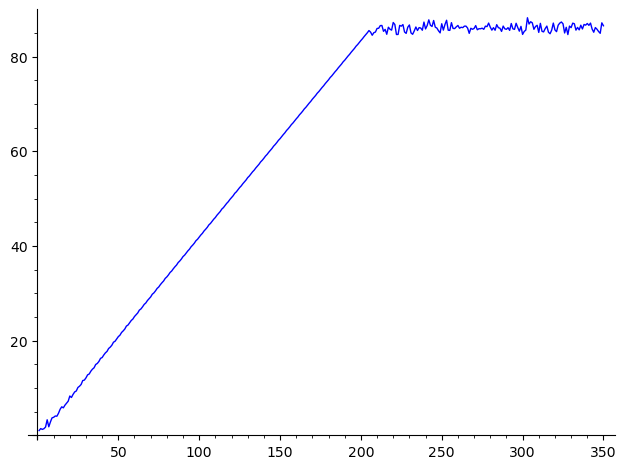

In [11]:
from sage.all import *
import pickle
import time

start=time.time()

def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return tr

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    newforms = S.newforms(names='a')

    results = []

    for f in newforms:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            continue

        tr = trace_functional(K)

        coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
        results.append(coeffs)

    return results


N=5
k=4
precision=500 
gos=galois_orbit_sum(N, k, precision)
print(gos[0][:10])
gos=gos[0][1:] # gos has just one newform and this line deletes its constant term

indexed_list=gos



h_list=[1]+indexed_list 
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in range(1,n):
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    j_list.append((n,j_n))
    if n%20==0:
        print(("j_list",n))

with open('/Users/barrybrent/data2/run10apr26no11.txt', 'wb') as wfile:
    pickle.dump(gos[0], wfile) #<<<<<< gos[0] bc len gos >=0
    
with open('/Users/barrybrent/data2/run10apr26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable


charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    now=time.time()
    elapsed=(now-start)/60
    print((n,elapsed))
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run10apr26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run10apr26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run10apr26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped